In [1]:
from dataset import RADIal
from encoder import ra_encoder
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import sys 
sys.path.append('/home/skouff/')
from RADIal.SignalProcessing.rpl import RadarSignalProcessing
from RADIal.DBReader import SyncReader
import numpy as np
import os


-------------------------------------------------------------------------
- Sensors available:
-     radar_ch2
-     radar_ch3
-     camera
-     gps
-     radar_ch0
-     scala
-     can
-     radar_ch1
-
- You might use function "setSensorFilters" to select sensors you want to read!
-------------------------------------------------------------------------
Total tolerance errors:  4.545454545454546 %
Total corrupted frames:  0.0 %
CuPy on GPU will be used to execute the processing


(np.float64(-0.5), np.float64(959.5), np.float64(539.5), np.float64(-0.5))

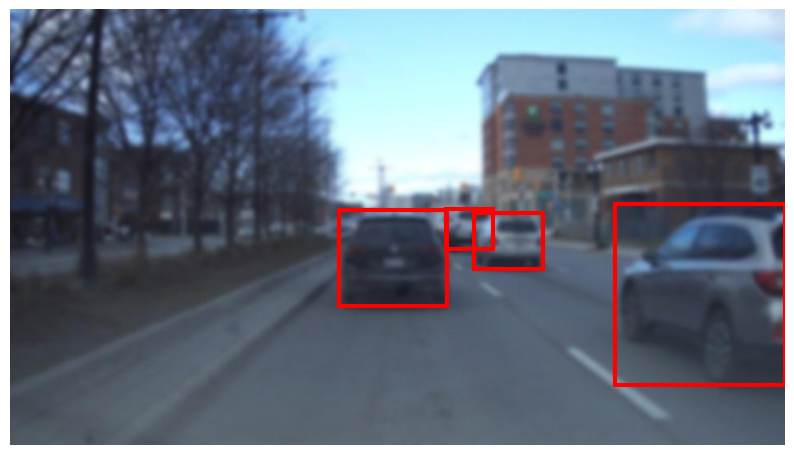

In [21]:
config = {
    "data_mode":"RD",
    "dataset": {
        "root_dir": "/Benson_DATA3/Public/RADIal/ready_to_use/RADIal/",
        "geometry":{
            "ranges": [512,896,1],
            "resolution": [0.201171875,0.2],
            "size": 3
        },
        "statistics":{
            "input_mean":[-2.62437651e-03, -2.13345470e-01,  1.87890028e-02, -1.44272549e+00,
               -3.76185047e-01,  1.35935890e+00, -2.29865852e-01,  1.22432935e-01,
                1.73593029e+00, -6.53456097e-01,  3.79762385e-01,  5.55212892e+00,
                7.74623837e-01, -1.55886042e+00, -7.24735683e-01,  1.51824262e+00,
               -3.71890112e-01, -8.83323401e-02, -1.61938504e-01,  1.09838836e+00,
                9.99290420e-01, -1.04952120e+00,  1.99716390e+00,  9.28686109e-01,
                1.89906800e+00, -2.37724935e-01,  1.99996778e+00,  7.77374669e-01,
                1.32391419e+00,  1.18174904e+00, -6.96956490e-01,  4.42879647e-01],
            "input_std":[20775.32866954, 23085.38586781, 23017.53041219, 14548.55197203,
                 32133.36398373, 28838.72008902, 27195.74436859, 33103.59882674,
                 32181.40955515, 35022.0350309,  31259.08457192, 36684.42768439,
                 33552.77541718, 25958.69536146, 29532.48663633, 32646.76200793,
                 20728.21451047, 23160.77110769, 23068.97650426, 14915.83084849,
                 32149.49991635, 28958.47224165, 27210.72879388, 33005.5213712,
                 31905.82548318, 35124.76263393, 31258.3364471,  31085.84958294,
                 33628.4113574,  25950.13585943, 29445.21585193, 32885.56853172],
            "reg_mean":[0.4048094369863972,0.3997392847799934],
            "reg_std":[0.6968599580482511,0.6942950877813826]
        }
    },
}
enc = ra_encoder(geometry = config['dataset']['geometry'],
                        statistics = config['dataset']['statistics'],
                        regression_layer = 2)

dataset = RADIal(root_dir = config['dataset']['root_dir'],
                        statistics= config['dataset']['statistics'],
                        encoder=enc.encode,
                        difficult=True,perform_FFT=config['data_mode'])
root_folder = '/Benson_DATA3/Public/RADIal/raw_sequences/RECORD@2020-11-21_13.44.44'
db = SyncReader(root_folder,tolerance=40000)

RSP = RadarSignalProcessing('/home/skouff/RADIal/SignalProcessing/CalibrationTable.npy',method='RA',device='cuda',lib='CuPy')
sample = db.GetSensorData(26)
ra= RSP.run(sample['radar_ch0']['data'],sample['radar_ch1']['data'],sample['radar_ch2']['data'],sample['radar_ch3']['data'])

item = dataset[0]
radar_FFT = item[0]
segmap = item[1]
out_label = item[2]
box_labels = item[3]
image = item[4]


fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(image)
for box in box_labels:
    if box[0] == -1 : 
        break
    rect = Rectangle(box[6:8]/2,(box[8]-box[6])/2,(box[9]-box[7])/2,linewidth=3, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
ax.axis('off')

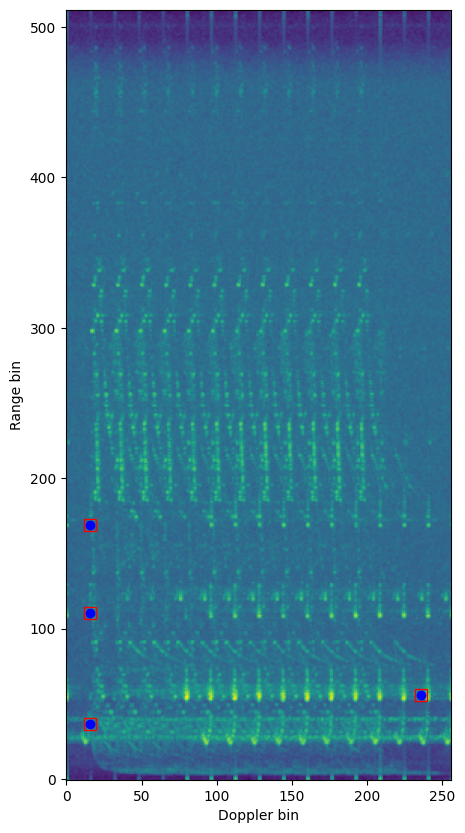

In [22]:
import matplotlib.patches as patches

radar_FFT = radar_FFT[...,::2]+1j*radar_FFT[...,1::2]
power_spectrum = np.sum(np.abs(radar_FFT),axis=2)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(np.log10(power_spectrum), origin='lower')

half_doppler_bins = 4
half_range_bins = 4

for box in box_labels:
    if(box[0]==-1):
        break # -1 means no object
    Range = box[0] * 512/103 # 512 range bins for 103m
    Doppler = box[2]

    x_corner = Doppler - half_doppler_bins
    y_corner = Range - half_range_bins

    rect = patches.Rectangle((x_corner, y_corner), 2*half_doppler_bins, 2*half_range_bins, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.plot(Doppler, Range, 'bo')
ax.set_xlabel('Doppler bin')
ax.set_ylabel('Range bin')
plt.show()

[]

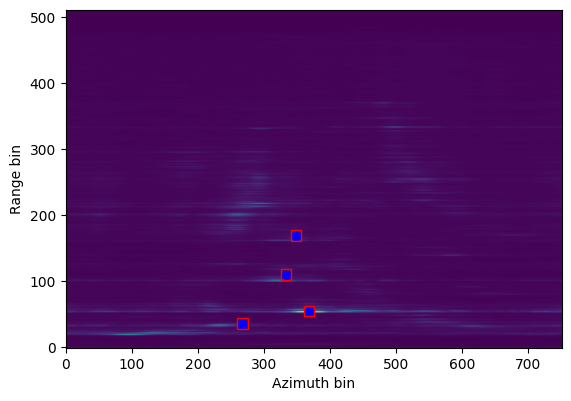

In [34]:
fig, ax = plt.subplots()
ax.imshow(ra, origin='lower')

N = ra.shape[1]  # largeur de l'image
M = ra.shape[0]  # hauteur de l'image
max_range = 103 
half_azimuth_bins = 8
half_range_bins = 8
for box in box_labels:
    if(box[0]==-1):
        break # -1 means no object
    azimuth_deg = box[1]  # radar_A_deg
    range_m = box[0] 
    azimuth_bin = int((azimuth_deg + 90) * (N / 180))
    range_bin = int(range_m * (M / max_range))

    x_corner = azimuth_bin - half_azimuth_bins
    y_corner = range_bin - half_range_bins

    rect = patches.Rectangle((x_corner, y_corner), 2*half_azimuth_bins, 2*half_range_bins, linewidth=1, edgecolor='r', facecolor='none', zorder=3)
    ax.add_patch(rect)
    ax.plot(azimuth_bin, range_bin, 'bo', zorder=2)
ax.set_xlabel('Azimuth bin')
ax.set_ylabel('Range bin')
plt.plot()